# Posterior Check via MIRA

Evaluate the **conditional (posterior) accuracy** of the strong-lensing source
reconstructions with [MIRA](../mira-score) (*A Score for Conditional Distribution
Accuracy and Model Comparison*).

For each true source galaxy we have a set of posterior draws produced by
`src/sample.py` (`samples/posterior_draws.pt`). MIRA asks whether, across **many**
such (truth, posterior) pairs, the truth behaves like a typical posterior draw
(good calibration) rather than sitting outside a too-tight posterior
(over-confident) or being swamped by a too-wide one (under-confident). It also
lets us **compare models** (e.g. different checkpoints or noise levels) on the
same set of sources.

**MIRA** (`mira_score.mira`):

```
mira(truth, posterior, num_runs=100, norm=False, ...) -> (score (M,), std (M,))
    truth      : (T, q)         T ground-truth vectors in q dims
    posterior  : (M, T, S, q)   M models, T truths, S samples each, q dims
```

so we map: **one truth = one source**, **q = image features** (PCA of the
flattened image), **S = posterior draws per source**, **M = models**.

### Running on Google Colab
This is the Colab version of the check. **Section 1** installs
`mira-score`, mounts Google Drive, clones the repository at the `local`
branch into `/content`, and symlinks `outputs/` to the copy stored on Drive
(`MyDrive/DIS-Project-Lensed-Galaxy/outputs`) so the auto-discovery in
Section 2 finds real posterior runs without HPC access. Then Run All.

### Testing without a checkpoint / HPC data
- **Section 3** is a self-contained **MIRA smoke test** (Gaussian toy) that runs
  immediately and confirms the score direction.
- **Section 4** optionally **fabricates `posterior_draws.pt` files** so the *real*
  loading + PCA + scoring path (Sections 5-8) also runs with no model. Set
  `MAKE_TOY_DATA = True` and Run All.
- With real runs present under `outputs/`, leave `MAKE_TOY_DATA = False` and the
  same cells score your actual posteriors.

## 1. Setup

In [1]:
!pip -q install mira-score==0.1.7

from google.colab import drive
drive.mount("/content/drive")

!git clone --branch local --depth 1 \
    https://github.com/Derrickdc02/DIS-Project-Lensed-Galaxy.git \
    /content/DIS-Project-Lensed-Galaxy

%cd /content/DIS-Project-Lensed-Galaxy

!ln -sfn \
    "/content/drive/MyDrive/DIS-Project-Lensed-Galaxy/outputs" \
    "/content/DIS-Project-Lensed-Galaxy/outputs"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path '/content/DIS-Project-Lensed-Galaxy' already exists and is not an empty directory.
/content/DIS-Project-Lensed-Galaxy


In [2]:
import sys, glob
from pathlib import Path

# Locate the project repo (dir with src/sample.py) and the MIRA repo, so the
# notebook runs regardless of the kernel's working directory. Wilkes3 absolute
# paths are added as fallbacks (same convention as PQMassPriorCheck.ipynb).
_repo_candidates = [Path.cwd(), *Path.cwd().parents,
                    Path("/rds/user/yd388/hpc-work/DIS-Project-Lensed-Galaxy")]
REPO = next(p for p in _repo_candidates if (p / "src" / "sample.py").exists())
sys.path.insert(0, str(REPO / "src"))

_mira_candidates = [REPO.parent / "mira-score",
                    Path("/rds/user/yd388/hpc-work/mira-score"),
                    Path.home() / "mira-score"]
MIRA_REPO = next((p for p in _mira_candidates
                  if (p / "src" / "mira_score" / "mira.py").exists()), None)

try:
    from mira_score import mira, mira_bootstrap, get_device
except ModuleNotFoundError:
    if MIRA_REPO is None:
        raise ModuleNotFoundError(
            "mira_score not importable and the mira-score repo was not found next "
            "to the project. Either `pip install -e ../mira-score` or set MIRA_REPO.")
    sys.path.insert(0, str(MIRA_REPO / "src"))
    from mira_score import mira, mira_bootstrap, get_device

import numpy as np
import torch
import matplotlib.pyplot as plt

device = get_device()
print(f"repo:      {REPO}")
print(f"mira repo: {MIRA_REPO}")
print(f"device:    {device}")

repo:      /content/DIS-Project-Lensed-Galaxy
mira repo: None
device:    cpu


## 2. Configuration

MIRA may evaluate either one candidate posterior model or several alternatives.
This analysis uses one reproduced model evaluated on multiple source galaxies.
One "truth" is one true source galaxy, and its samples are the posterior
draws written by `src/sample.py` to `samples/posterior_draws.pt`. A single truth
is not sufficient for a meaningful population-level calibration assessment.

MODELS maps each candidate model to the run directories for the same set of
source galaxies. By default, all discovered runs under `outputs/` are treated
as truth cases for one model. Add another MODELS entry only when comparing a
genuine alternative, such as a different checkpoint, sampler or likelihood
approximation, evaluated on those same sources. Comparing observation-noise
levels is not required for the present MIRA test. The covariance-rescaled
baselines constructed below are sensitivity controls, not additional models
trained or sampled at different observation-noise levels.

In [3]:
def discover_runs():
    found = sorted(glob.glob(str(REPO / "outputs" / "**" / "samples" /
                                 "posterior_draws.pt"), recursive=True))
    return [str(Path(p).parent.parent) for p in found]

_run_dirs = discover_runs()
MODELS = {"model": _run_dirs}      # <- replace to compare several models

USE_PCA       = True   # project flattened images to PCA_DIMS before scoring
                       # (recommended; raw images are too high-dim for
                       # distance-based scores -- see the PQMass notebook).
PCA_DIMS      = 50
NORM          = True   # MIRA min-max normalisation of the score space
NUM_RUNS      = 200    # Monte-Carlo replications inside mira()
NUM_BOOTSTRAP = 200    # resamples for mira_bootstrap() uncertainty
ADD_BASELINES = True   # add directional over-/under-confidence checks
OVER_SCALE    = 1.0 / np.sqrt(3.0)  # covariance = 1/3 of the base posterior
UNDER_SCALE   = np.sqrt(2.0)        # covariance = 2 times the base posterior
SEED          = 21

torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Discovered {len(_run_dirs)} posterior run(s) under outputs/:")
for r in _run_dirs:
    print("  ", r)
HAVE_DATA = len(_run_dirs) > 0
if not HAVE_DATA:
    print("\nNo posterior_draws.pt found yet. Run the toy generator in Section 4 "
          "(MAKE_TOY_DATA=True) to exercise the full pipeline, or point MODELS at "
          "real runs. The Section 3 smoke test runs regardless.")

Discovered 16 posterior run(s) under outputs/:
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Courteau97_UGC10655
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Courteau97_UGC10706
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Courteau97_UGC4461
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson92_ESO351-g1
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson92_ESO549-g18
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson92_NGC1337
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson92_NGC755
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson96_ESO297-G29
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson96_ESO354-G47
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson96_ESO552-G15
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_Mathewson96_IC728
   /content/DIS-Project-Lensed-Galaxy/outputs/mira/pick_SCII_AGC200768
   /content/DIS-Project-Lensed-Galax

## 3. Synthetic smoke test (runs now, no files)

Verify that MIRA imports and our calling convention is right, and confirm the
**score direction**. Truths are drawn from `N(m, I)`. The matched posterior has
covariance `I`; the deliberately over-confident and under-confident candidates
have covariances `I/3` and `2I`. These reproduce the relative covariance
mismatches used in the Gaussian experiment of Sharief et al. The expected
directions are over-confident below `2/3`, matched near `2/3`, and
under-confident above `2/3`.

In [4]:
def _make_gaussian_case(spread, T=200, S=100, q=5, seed=0):
    g = torch.Generator().manual_seed(seed)
    centers = torch.randn(T, q, generator=g)                # per-truth mean m_t
    truth   = centers + torch.randn(T, q, generator=g)      # truth ~ N(m_t, I)
    samples = (centers[:, None, :] +
               spread * torch.randn(T, S, q, generator=g))  # post ~ N(m_t, spread^2 I)
    return truth, samples

truth_s, cal   = _make_gaussian_case(1.0, seed=1)
_,       over  = _make_gaussian_case(OVER_SCALE, seed=1)
_,       under = _make_gaussian_case(UNDER_SCALE, seed=1)
post_s  = torch.stack([cal, over, under], dim=0)    # (M=3, T, S, q)
names_s = ["matched", "over-confident (covariance / 3)",
           "under-confident (covariance x 2)"]

score_s, std_s = mira(truth_s, post_s, num_runs=NUM_RUNS, norm=False, device=device)
for n, m, sd in zip(names_s, score_s.tolist(), std_s.tolist()):
    print(f"  {n:38s}  MIRA = {m:.4f} +/- {sd:.4f}")
print("\nExpected direction: over-confident < 2/3, matched ~= 2/3, "
      "under-confident > 2/3.")

Mira MC runs: 100%|██████████| 200/200 [00:00<00:00, 422.40it/s]

  matched                                 MIRA = 0.6689 +/- 0.0158
  over-confident (covariance / 3)         MIRA = 0.6164 +/- 0.0173
  under-confident (covariance x 2)        MIRA = 0.6678 +/- 0.0151

Expected direction: over-confident < 2/3, matched ~= 2/3, under-confident > 2/3.


## 4. Optional: generate a toy dataset

Fabricate `posterior_draws.pt` files that match the schema written by
`src/sample.py`, so Sections 5-8 run end-to-end **without a checkpoint or HPC
samples**. Each toy source is a smooth Gaussian "galaxy" blob; the truth and the
`S` posterior draws are independent draws of `N(m_t, TAU^2)` and are therefore
exchangeable. The toy posterior should consequently score near the matched
reference `2/3`. `outputs/` is gitignored, so this is throwaway scratch.

In [5]:
MAKE_TOY_DATA = False        # <- set True, then Run All, to test without a checkpoint

if MAKE_TOY_DATA:
    import shutil
    T_TOY, S_TOY, H_TOY, TAU = 16, 64, 32, 0.15
    toy_root = REPO / "outputs" / "toy_mira"
    if toy_root.exists():
        shutil.rmtree(toy_root)
    g = torch.Generator().manual_seed(SEED)
    yy, xx = torch.meshgrid(torch.linspace(-1, 1, H_TOY),
                            torch.linspace(-1, 1, H_TOY), indexing="ij")
    for t in range(T_TOY):
        cx, cy = (torch.rand(2, generator=g) * 1.2 - 0.6).tolist()   # blob centre
        w = 0.15 + 0.25 * torch.rand(1, generator=g).item()          # blob width
        m = torch.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * w * w)))  # (H,H) in [0,1]
        m = (2 * m - 1).float()                                            # -> [-1,1]
        # truth and draws are exchangeable draws of N(m_t, TAU^2) -> calibrated
        src  = (m + TAU * torch.randn(H_TOY, H_TOY, generator=g)).clamp(-1, 1)
        post = (m[None, None] +
                TAU * torch.randn(S_TOY, 1, H_TOY, H_TOY, generator=g)).clamp(-1, 1)
        d = {"post": post, "src": src[None], "obs": src[None].clone(),
             "pick": t, "src_name": f"toy_{t:02d}", "noise_sigma": TAU,
             "steps": 0, "image_pool": 2}
        run = toy_root / f"pick{t:02d}" / "samples"
        run.mkdir(parents=True, exist_ok=True)
        torch.save(d, run / "posterior_draws.pt")
    _run_dirs = discover_runs()
    MODELS = {"toy": _run_dirs}
    HAVE_DATA = len(_run_dirs) > 0
    print(f"Wrote {T_TOY} toy runs under {toy_root}")
    print(f"discovered runs = {len(_run_dirs)}, HAVE_DATA = {HAVE_DATA}")
else:
    print("MAKE_TOY_DATA is False -> using whatever was discovered in Section 2.")

MAKE_TOY_DATA is False -> using whatever was discovered in Section 2.


## 5. Load posterior draws

Each `samples/posterior_draws.pt` holds one true source (`src`) and its draws
(`post`, shape `(S, 1, H, W)`). We key truths by `src_name` so every model is
scored on the SAME sources, flatten images to `(H*W,)`, and trim to a common
number of samples `S`.

In [6]:
def _load_run(run_dir):
    d = torch.load(Path(run_dir) / "samples" / "posterior_draws.pt",
                   map_location="cpu", weights_only=False)
    post = d["post"].float().squeeze(1)                 # (S, H, W)
    src  = d["src"].float().squeeze()                   # (H, W)
    name = d.get("src_name", Path(run_dir).name)
    return name, src.reshape(-1), post.reshape(post.shape[0], -1)

if HAVE_DATA:
    per_model, truth_by_name = {}, {}
    for mname, dirs in MODELS.items():
        per_model[mname] = {}
        for rd in dirs:
            name, src_flat, post_flat = _load_run(rd)
            per_model[mname][name] = post_flat
            truth_by_name.setdefault(name, src_flat)

    # Truths common to every model (MIRA needs a shared truth set).
    common = sorted(set.intersection(*[set(m) for m in per_model.values()]))
    if not common:
        HAVE_DATA = False
        print("No sources are shared across all models -> nothing to score.")
    else:
        S = min(per_model[m][n].shape[0] for m in per_model for n in common)
        D = truth_by_name[common[0]].numel()
        model_names = list(per_model.keys())
        M, T = len(model_names), len(common)
        print(f"models M={M}, truths T={T}, samples/truth S={S}, pixel dim D={D}")
        if T < 5:
            print("WARNING: very few truths -- MIRA is only meaningful with many "
                  "source picks. Sample more --pick values for a real test.")
        truth_px = torch.stack([truth_by_name[n] for n in common], dim=0)   # (T, D)
        post_px  = torch.stack([torch.stack([per_model[m][n][:S] for n in common])
                                for m in model_names], dim=0)               # (M, T, S, D)
else:
    print("No data -> skipping real-data load.")

models M=1, truths T=16, samples/truth S=160, pixel dim D=65536


## 6. Build the MIRA feature space

Distance-based scores degrade in very high dimensions, so (like the PQMass PCA
cross-check) we project both truths and posterior samples onto the top principal
components of the **combined** stack -- a neutral basis -- to get `q = PCA_DIMS`.

In [7]:
if HAVE_DATA:
    if USE_PCA:
        k = min(PCA_DIMS, D)
        stack = torch.cat([truth_px, post_px.reshape(-1, D)], dim=0).numpy()
        mean  = stack.mean(0, keepdims=True)
        _, _, Vt = np.linalg.svd(stack - mean, full_matrices=False)
        comps  = torch.from_numpy(Vt[:k]).float()               # (k, D)
        mean_t = torch.from_numpy(mean).float()
        proj = lambda x: (x - mean_t) @ comps.T
        truth_q = proj(truth_px)                                # (T, k)
        post_q  = proj(post_px.reshape(-1, D)).reshape(M, T, S, k)
        print(f"MIRA space: PCA({k})")
    else:
        truth_q, post_q = truth_px, post_px
        print(f"MIRA space: raw pixels ({D}) -- high-dimensional, interpret with care")

MIRA space: PCA(50)


## 7. Run MIRA (+ bootstrap)

Optionally append two **directional sensitivity checks** by shrinking and
inflating the first model's posterior about its per-truth mean. Their covariance
ratios match the Gaussian experiment of Sharief et al. They are not calibration
thresholds: the primary comparison is with the matched reference `2/3` and its
uncertainty, while the checks verify the expected score direction.

In [8]:
if HAVE_DATA:
    names, post_all = list(model_names), post_q
    if ADD_BASELINES:
        base = post_q[0:1]                              # (1, T, S, q)
        mu   = base.mean(dim=2, keepdim=True)
        overc  = mu + OVER_SCALE * (base - mu)
        underc = mu + UNDER_SCALE * (base - mu)
        post_all = torch.cat([post_q, overc, underc], dim=0)
        names = names + [f"{model_names[0]} [over-conf: covariance / 3]",
                         f"{model_names[0]} [under-conf: covariance x 2]"]

    score, std = mira(truth_q, post_all, num_runs=NUM_RUNS, norm=NORM, device=device)
    bmean, bstd = mira_bootstrap(truth_q, post_all, num_bootstrap=NUM_BOOTSTRAP,
                                 num_runs=1, norm=NORM, device=device)
    print(f"{'model':48s} {'MIRA':>8s} {'std':>8s} {'boot_std':>9s}")
    for n, m, sd, bs in zip(names, score.tolist(), std.tolist(), bstd.tolist()):
        print(f"{n:48s} {m:8.4f} {sd:8.4f} {bs:9.4f}")

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 597.22it/s]
/usr/local/lib/python3.12/dist-packages/mira_score/mira.py:124: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std_score = total_score.std(dim=0, unbiased=True)  # (M,)

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 755.46it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 501.35it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 640.16it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 468.48it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 822.25it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 477.98it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 766.64it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 561.94it/s]

Mira MC runs: 100%|██████████| 1/1 [00:00<00:00, 460.81it/s]

Mira MC runs: 100%|██████████| 1

model                                                MIRA      std  boot_std
model                                              0.6379   0.0578    0.0621
model [over-conf: covariance / 3]                  0.5782   0.0668    0.0691
model [under-conf: covariance x 2]                 0.6827   0.0559    0.0595


## 8. Plot the scores

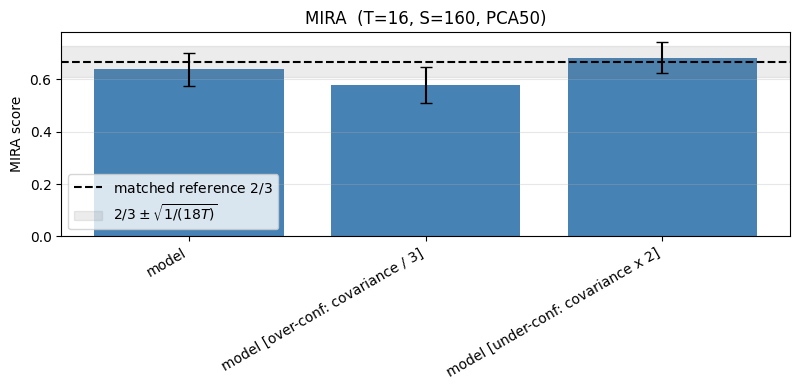

In [9]:
if HAVE_DATA:
    x = np.arange(len(names))
    theory_mean = 2.0 / 3.0
    theory_sd = np.sqrt(1.0 / (18.0 * T))

    fig, ax = plt.subplots(figsize=(1.7 * len(names) + 3, 4))
    ax.bar(x, score.cpu().numpy(), yerr=bstd.cpu().numpy(), capsize=4, color="steelblue")
    ax.axhline(theory_mean, color="black", linestyle="--",
               label=r"matched reference $2/3$")
    ax.axhspan(theory_mean - theory_sd, theory_mean + theory_sd,
               color="grey", alpha=0.15,
               label=r"$2/3 \pm \sqrt{1/(18T)}$")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_ylabel("MIRA score")
    ax.set_title(f"MIRA  (T={T}, S={S}, " + (f"PCA{min(PCA_DIMS, D)}" if USE_PCA else f"{D}px") + ")")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout(); plt.show()

Saved: /content/DIS-Project-Lensed-Galaxy/mira_posterior_calibration.png
Saved: /content/DIS-Project-Lensed-Galaxy/mira_posterior_calibration.pdf


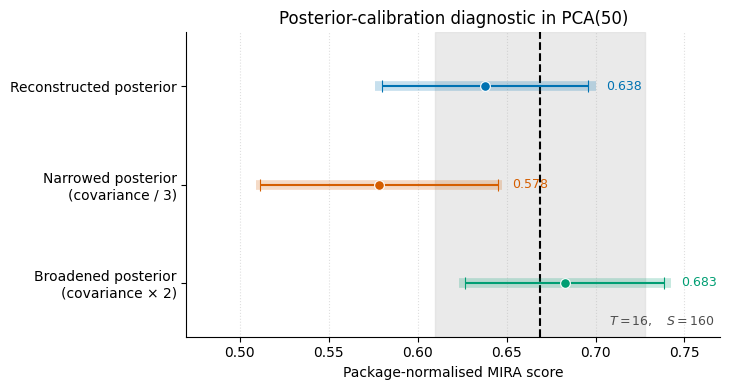

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

T, S = 16, 160
labels = [
    "Reconstructed posterior",
    "Narrowed posterior\n(covariance / 3)",
    "Broadened posterior\n(covariance × 2)",
]
scores = np.array([0.6379, 0.5782, 0.6827])
mc_sd = np.array([0.0578, 0.0668, 0.0559])
bootstrap_sd = np.array([0.0621, 0.0691, 0.0595])
colors = ["#0072B2", "#D55E00", "#009E73"]

matched_ref = (2 * S + 1) / (3 * S)
ref_sd = np.sqrt(1.0 / (18.0 * T))

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.axvspan(
    matched_ref - ref_sd, matched_ref + ref_sd, color="0.85", alpha=0.55, zorder=0
)
ax.axvline(matched_ref, color="black", linestyle="--", linewidth=1.5, zorder=1)

for i, (val, mc, boot, col) in enumerate(zip(scores, mc_sd, bootstrap_sd, colors)):
    ax.hlines(i, val - boot, val + boot, color=col, linewidth=7, alpha=0.22, zorder=2)
    ax.errorbar(
        val, i, xerr=mc, fmt="o", ms=7, color=col, mec="white", mew=0.8,
        elinewidth=1.5, capsize=4, capthick=1.4, zorder=3
    )
    ax.text(val + boot + 0.006, i, f"{val:.3f}", va="center", color=col, fontsize=9)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0.47, 0.77)
ax.set_ylim(len(labels) - 0.45, -0.55)

ax.set_xlabel("Package-normalised MIRA score")
ax.set_title("Posterior-calibration diagnostic in PCA(50)")
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.4)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.text(
    0.99, 0.03, rf"$T={T},\quad S={S}$", transform=ax.transAxes,
    ha="right", va="bottom", fontsize=9, color="0.3"
)
plt.tight_layout()

out_dir = Path.cwd()
for ext in ["png", "pdf"]:
    path = out_dir / f"mira_posterior_calibration.{ext}"
    fig.savefig(path, dpi=300 if ext == "png" else None, bbox_inches="tight")
    print(f"Saved: {path}")

plt.show()

In [11]:
projected_stack = np.concatenate(
    [
        truth_q.cpu().numpy(),
        post_q.reshape(-1, post_q.shape[-1]).cpu().numpy(),
    ],
    axis=0,
)

mira_pca_retained_variance = (
    np.sum(projected_stack.astype(np.float64) ** 2)
    / np.sum((stack - mean).astype(np.float64) ** 2)
)

print(
    "MIRA PCA(50) retained variance: "
    f"{100 * mira_pca_retained_variance:.2f}%"
)

MIRA PCA(50) retained variance: 99.61%


## 9. Interpretation

- **Matched reference**: a correctly specified candidate has an asymptotic MIRA
  score of `2/3`, with theoretical standard uncertainty `sqrt(1 / (18T))`. Use
  the bootstrap uncertainty over truths for the reported finite-sample result.
- **Score direction**: the deliberately narrow candidate should fall below
  `2/3`, while the deliberately broad candidate should rise above it. These are
  sensitivity checks, not acceptance thresholds. A score below `2/3` is not
  uniquely diagnostic of over-confidence because bias can also lower the score.
- **Model comparison**: when several models are evaluated on the same truths,
  compare their distance from the matched reference together with uncertainty;
  the numerically largest score is not necessarily the best-calibrated one.
- **Representation**: the reported calculation uses one common PCA basis. Record
  the retained variance and treat a raw-pixel calculation only as a sensitivity
  check for the chosen feature space.